Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
FX-ALPHALAB - CORRELATION AGENT
Version Complète & Structurée

1. BUSINESS UNDERSTANDING & ANALYTIC APPROACH

BO1 → Enhance estimation performance
BO2 → React quickly to market
BO3 → Signal quality
BO4 → Risk reduction

DSO1 → Prediction
DSO2 → Real-time models
DSO3 → Multi-agent system
DSO4 → Correlation + Markov regime detection


2. DATA ACQUISITION
✓ EURUSD chargé → 2121 lignes
✓ GBPUSD chargé → 2121 lignes
✓ USDJPY chargé → 2121 lignes
✓ EURJPY chargé → 2121 lignes
✓ USDCHF chargé → 2121 lignes

Données : 2121 jours × 5 paires

PAIR: EURUSD
Sharpe: 0.952
Decision: HOLD
Monte Carlo Prob Profit: 91.0%


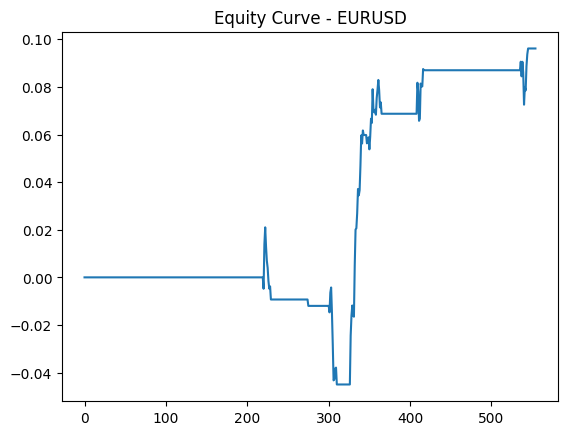

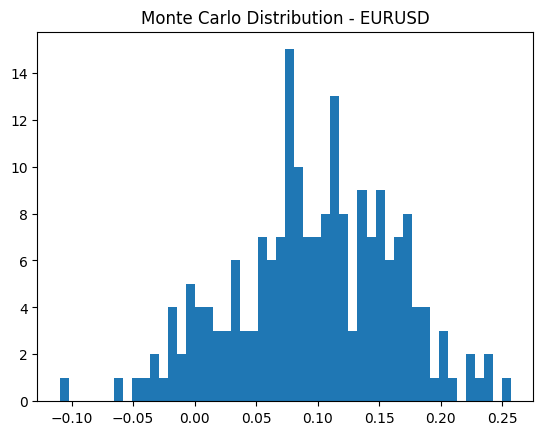

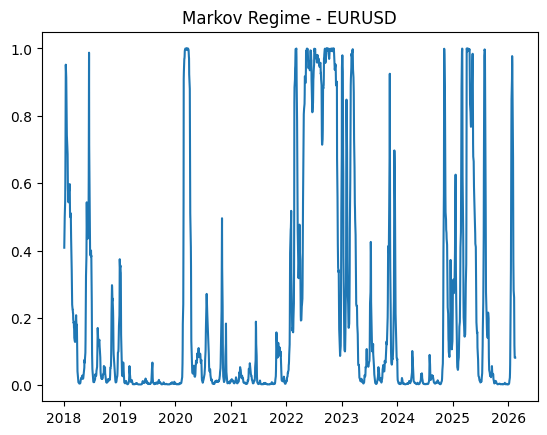


PAIR: GBPUSD
Sharpe: -0.02
Decision: HOLD
Monte Carlo Prob Profit: 44.0%


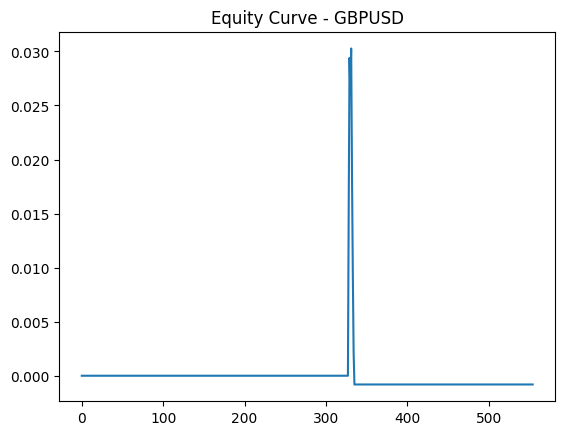

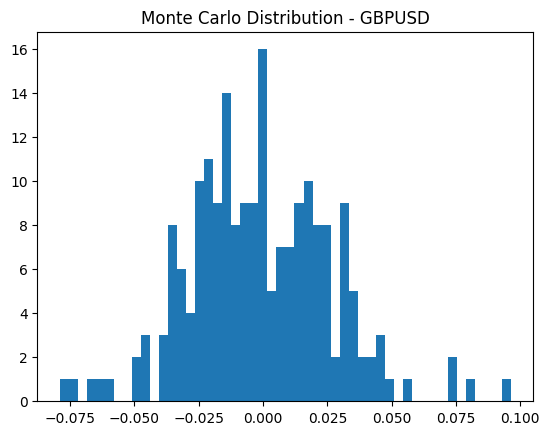

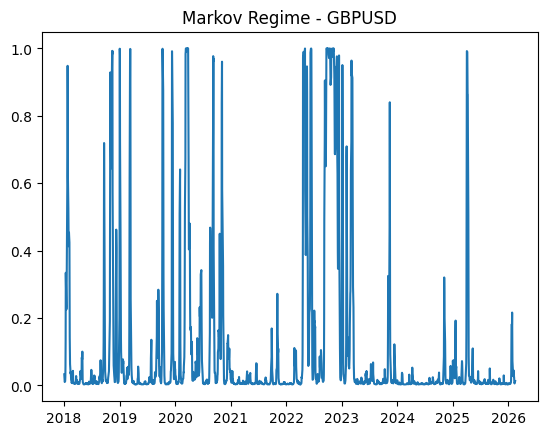


PAIR: USDJPY
Sharpe: 0.571
Decision: BUY
Monte Carlo Prob Profit: 79.0%


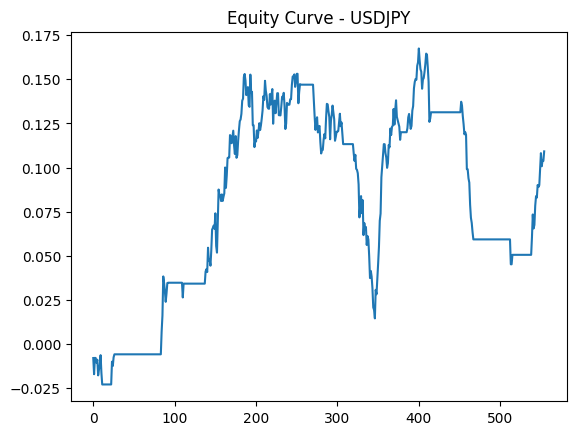

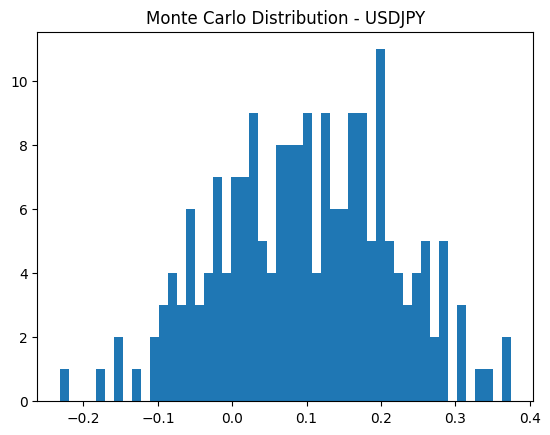

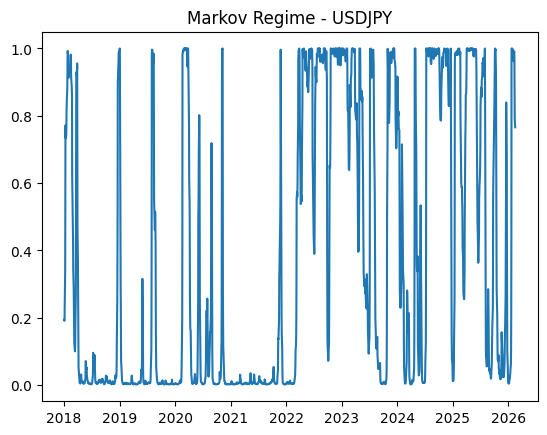


PAIR: EURJPY
Sharpe: 0.03
Decision: BUY
Monte Carlo Prob Profit: 54.5%


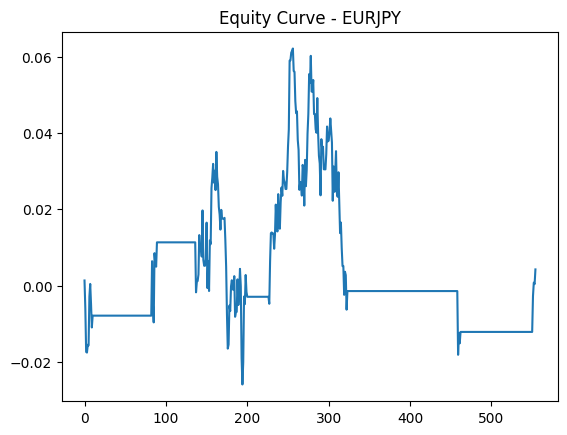

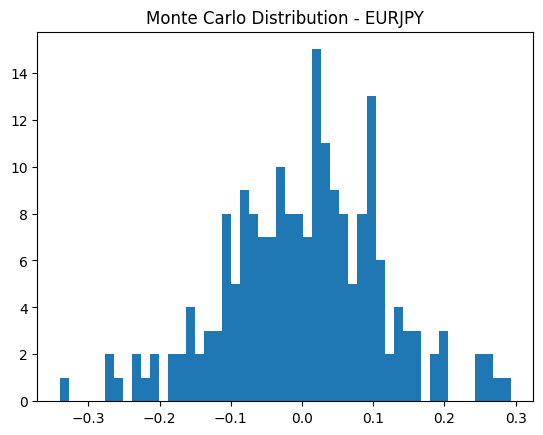

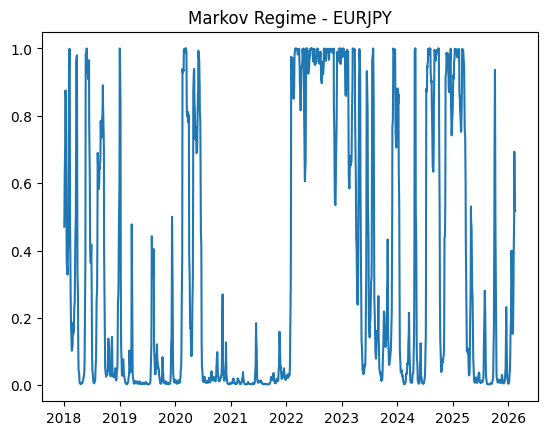


PAIR: USDCHF
Sharpe: 0.298
Decision: HOLD
Monte Carlo Prob Profit: 71.5%


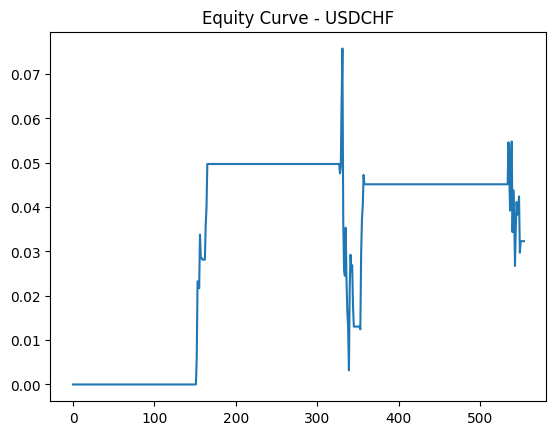

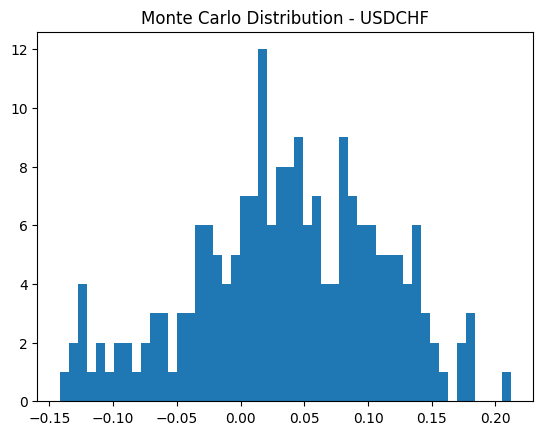

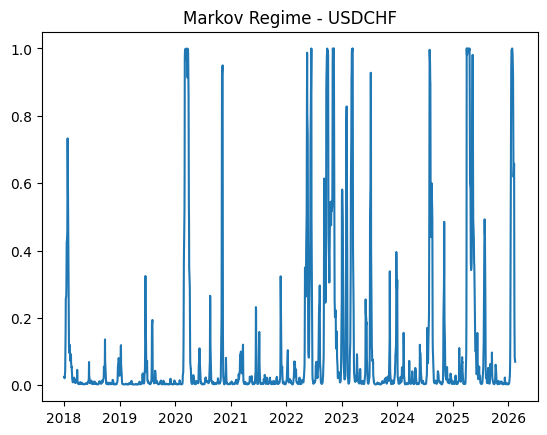


RÉSULTATS FINAUX
     Pair    Sharpe Decision  Prob_Profit
0  EURUSD  0.952300     HOLD        0.910
1  GBPUSD -0.019943     HOLD        0.440
2  USDJPY  0.570870      BUY        0.790
3  EURJPY  0.030287      BUY        0.545
4  USDCHF  0.297700     HOLD        0.715

🔥 BEST PAIR FOR TRADING:
Pair           EURUSD
Sharpe         0.9523
Decision         HOLD
Prob_Profit      0.91
Name: 0, dtype: object


In [7]:
# ============================================================
# FX-ALPHALAB - FINAL COLAB VERSION (STRUCTURED + GRAPHS)
# ============================================================

# ================= INSTALL =================
!pip install xgboost statsmodels

# ================= IMPORT =================
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

# ================= DRIVE =================
from google.colab import drive
drive.mount('/content/drive')

# ================= CONFIG =================
PAIRS = ["EURUSD", "GBPUSD", "USDJPY", "EURJPY", "USDCHF"]
SPLIT_DATE = "2024-01-01"

PROBA_BUY = 0.55
PROBA_SELL = 0.45

DATA_DIR = "/content/drive/MyDrive/live_data"

np.random.seed(42)

# ================= FUNCTIONS =================
def sharpe(pnl):
    pnl = np.array(pnl)
    if np.std(pnl) == 0:
        return 0
    return np.mean(pnl)/(np.std(pnl)+1e-9)*np.sqrt(252)

def monte_carlo(pnl, n_sim=200):
    results = []
    for _ in range(n_sim):
        sim = np.random.choice(pnl, size=len(pnl), replace=True)
        results.append(np.sum(sim))
    return np.array(results)

def detect_regime(series):
    try:
        model = MarkovRegression(series, k_regimes=2, trend='c', switching_variance=True)
        res = model.fit(disp=False)
        return res.smoothed_marginal_probabilities[1]
    except:
        return pd.Series(0.5, index=series.index)

# ============================================================
# 1. BUSINESS
# ============================================================

print("="*100)
print("FX-ALPHALAB - CORRELATION AGENT")
print("Version Complète & Structurée")
print("="*100)

print("\n1. BUSINESS UNDERSTANDING & ANALYTIC APPROACH")
print("="*80)

print("""
BO1 → Enhance estimation performance
BO2 → React quickly to market
BO3 → Signal quality
BO4 → Risk reduction

DSO1 → Prediction
DSO2 → Real-time models
DSO3 → Multi-agent system
DSO4 → Correlation + Markov regime detection
""")

# ============================================================
# 2. DATA
# ============================================================

print("\n2. DATA ACQUISITION")
print("="*80)

prices = {}

for pair in PAIRS:
    path = os.path.join(DATA_DIR, f"{pair}_from_2018.csv")

    if os.path.exists(path):
        df = pd.read_csv(path, parse_dates=[0], index_col=0)
        prices[pair] = df["Close"].astype(float)
        print(f"✓ {pair} chargé → {len(df)} lignes")

closes = pd.DataFrame(prices).sort_index()
returns = np.log(closes / closes.shift(1)).dropna()

print(f"\nDonnées : {closes.shape[0]} jours × {closes.shape[1]} paires")

# ============================================================
# 3. MODEL
# ============================================================

results = []

for pair in PAIRS:

    if pair not in closes.columns:
        continue

    print("\n" + "="*60)
    print(f"PAIR: {pair}")
    print("="*60)

    r = returns[pair]

    # ===== MARKOV =====
    regime = detect_regime(r)
    regime = regime.loc[r.index]

    # ===== FEATURES =====
    X = pd.DataFrame(index=r.index)
    X["lag1"] = r.shift(1)
    X["lag2"] = r.shift(2)
    X["vol"] = r.rolling(10).std()
    X["regime"] = regime

    # ===== TARGET =====
    y_reg = r.shift(-1)
    y_cls = (y_reg > 0).astype(int)

    data = X.copy()
    data["y_reg"] = y_reg
    data["y_cls"] = y_cls
    data = data.dropna()

    train = data[data.index < SPLIT_DATE]
    test = data[data.index >= SPLIT_DATE]

    X_train = train.drop(["y_reg","y_cls"], axis=1)
    X_test = test.drop(["y_reg","y_cls"], axis=1)

    ycls_train = train["y_cls"]
    yreg_test = test["y_reg"]

    # ===== MODEL =====
    model = xgb.XGBClassifier(n_estimators=200, eval_metric="logloss")
    model.fit(X_train, ycls_train)

    proba = model.predict_proba(X_test)[:,1]
    regime_test = X_test["regime"].values

    signal = np.where(
        (proba > PROBA_BUY) & (regime_test > 0.50), 1,
        np.where((proba < PROBA_SELL) & (regime_test > 0.50), -1, 0)
    )

    pnl = np.where(signal==1, yreg_test,
          np.where(signal==-1, -yreg_test, 0))

    sharpe_val = sharpe(pnl)
    mc = monte_carlo(pnl)
    prob_profit = np.mean(mc > 0)

    decision = ["HOLD","BUY","SELL"][[0,1,2][signal[-1]]]

    print(f"Sharpe: {round(sharpe_val,3)}")
    print(f"Decision: {decision}")
    print(f"Monte Carlo Prob Profit: {round(prob_profit*100,2)}%")

    # ================= GRAPH =================

    # Equity curve
    plt.figure()
    plt.plot(np.cumsum(pnl))
    plt.title(f"Equity Curve - {pair}")
    plt.show()

    # Monte Carlo
    plt.figure()
    plt.hist(mc, bins=50)
    plt.title(f"Monte Carlo Distribution - {pair}")
    plt.show()

    # Regime
    plt.figure()
    plt.plot(regime)
    plt.title(f"Markov Regime - {pair}")
    plt.show()

    results.append({
        "Pair": pair,
        "Sharpe": sharpe_val,
        "Decision": decision,
        "Prob_Profit": prob_profit
    })

# ============================================================
# FINAL
# ============================================================

summary = pd.DataFrame(results)

print("\n" + "="*100)
print("RÉSULTATS FINAUX")
print("="*100)
print(summary)

best = summary.sort_values("Sharpe", ascending=False).iloc[0]

print("\n🔥 BEST PAIR FOR TRADING:")
print(best)